**6장 - 결정 트리**

**결정 트리(decision tree)** 는 분류와 회귀 작업 그리고 다중 출력 작업까지 가능한 다목적 머신러닝 알고리즘임. 또한 매우 복접한 데이터셋도 학습할 수 있는 알고리즘임.

# 설정

이 프로젝트를 실행하려면 파이썬 3.7 이상이 필요함:

In [13]:
import sys

assert sys.version_info >= (3, 7)

또한 사이킷런 1.0.1 이상이 필요함:

In [14]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

기본 글꼴 크기를 정의함:

In [15]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

이미지를 저장할 경로와 함수를 정의함:

In [16]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_tree"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [17]:
from sklearn import set_config

set_config(display="text")

## 결정 트리 학습과 시각화

결정 트리를 이해하기 위해 모델 하나를 만들어 어떻게 예측을 하는지 확인.

DecisionTreeClassifier :

In [18]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

export_graphviz() 함수를 이용해 그래프 정의를 iris_tree.dot파일로 출력하여 훈련된 결정 트리르 시각화 할 수 있음.

In [19]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file=str(IMAGES_PATH / "iris_tree.dot"),
    feature_names=["petal length(cm)", "petal width(cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

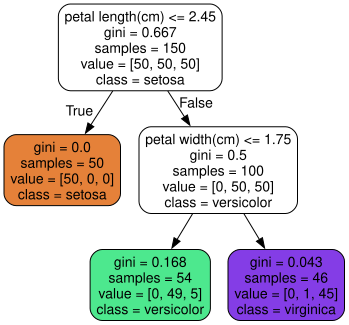

In [20]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree.dot")

Graphviz는 `.dot` 파일을 다양한 포맷으로 변환할 수 있는 'dot' 명령줄 도구도 제공함.

다음 명령어는 dot파일을 png 이미지로 변환

In [21]:
!dot -Tpng {IMAGES_PATH / "iris_tree.dot"} -o {IMAGES_PATH / "iris_tree.png"}

## 예측

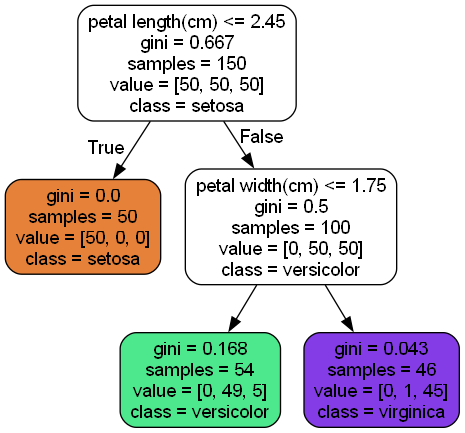

해당 트리가 어떻게 예측을 만들어냈는 방법.

꽃잎을 기준으로 하여 새로 발견하 붓꽃의 품종를 분류하려 한다고 가정하겠음.

1. **루트 노드(root node)** 에서 시작함. 이 노드는 꽃잎의 길이가 2.45cm보다 짧은지 검사함. 
2. 만약 그렇다면 루트 노드에서 왼쪽 자식 노드(child node)로 이동. 이 경우 이 노드가 **리프 노드(leaf node)** 이므로 추가적인 검사를 하지않음 그냥 노드에 있는 예측 클래스를 보고 결정 트리가 새로 바견한 꽃의 품종을 Iris-Setosa(class=setosa)라고 예측함.

또 다른 꽃을 발견했는데 이번엔 길이가 2.45보다 긺.
1. 다시 루트 노드에서 시작하지만 오른쪽 자식노드로 이동함. 
2. 추가로 '꽃잎의 너비가 1.75cm보다 작은지` 검사함.
3. 만약 그렇다면 Iris-Versicolor, 아니라면 Iris-Virginica

노드의 sample 속성은 얼마나 많은 훈련 샘플이 적용되었느지 헤아리는 것.

- 예) 100개의 훔련 샘플의 꽃잎 길이가 2.45cm 보다 길고, 그중 54개 샘플의 꽃ㅊ잎 너비가 1.75cm보다 짧음

노드의 value 속성은 노드에서 각 클래스에 얼마나 많은 훈련 샘플이 있는 알려줌.

- 예) 오른쪽 아래 노드는 Iris-Setosa가 0개이고, Iris-Versicolo가 1개, Iris-Virginica가 45개 였음

노드의 gini속성은 **지니 불순도(gini impurity)** 를 측정함. 한 노드의 모든 샘플이 같은 클래스에 속해 있다면 노드의 순수(gini=0)하다고 말함

- 예) 1의 왼쪽 노드는 Iris-Setosa 훈련 샘플만 가지고 있으므로 순수 노드이고 지니 불손도가 0임.

아래의 식은 훈련 알고리즘이 $i$번째 노드의 지니 불순도 $G_i$를 계산하는 방법을 보여줌.
깊이 2의 왼쪽 노드의 지니 불순도는 $1-(0 / 54)^2-(49/54)^2-(5/54)^2 \approx(0.168) $

지니 불순도 : 
$$
G_i = 1 - \sum_{k=1}^{n} (p_{i,k})^2
$$


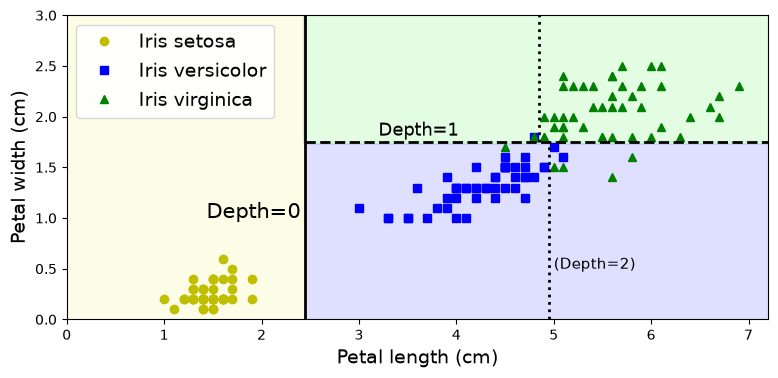

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()
save_fig("decision_tree_decision_boundaries_plot")

plt.show()

트리 구조는 `tree_` 속성을 통해 엑세스 가능

In [23]:
tree_clf.tree_

# 자세한 내용은 아래의 클래스 문서 참조
# help(sklearn.tree._tree.Tree)